# Coin Counting Machine

![coin_counter_image.png](https://live.staticflickr.com/65535/54326911769_4e446cdd97_k.jpg)
*Image generated using the Flux-dev model.*

## Introduction
Imagine you discover a large chest full of coins in the attic and decide to count their total value. Manual counting of each coin would be time-consuming and tedious, so you decide to automate the solution. Based on photos of scattered coins, your goal is to determine their total value.
Breaking this task down into its basic components, your task will be:
* locating each coin in the photo,
* assigning them to appropriate categories by denomination (e.g., 1 grosz or 2 złote).

In the field of computer vision, this task is called object detection. Note that detection means simultaneously performing classification and regression – you must determine both the object's class and its position in the image. An additional challenge that distinguishes detection from ordinary classification is that instead of a single object representing one class, there may be multiple objects of different classes in the image.

Formally, we can say that the solution $\hat{\mathcal{B}}$ should be a set of tuples containing, respectively, the coordinates of the rectangle containing the coin, a label specifying the coin's denomination, and the confidence with which the model believes it found a coin.
$$
\hat{\mathcal{B}} = \{(x_{min}, y_{min}, x_{max}, y_{max}, c, \phi), \dots\}
$$
where $(x_{min}, y_{min})$ is the top-left corner of the rectangle, $(x_{max}, y_{max})$ is the bottom-right corner, $c$ is the coin label, and $\phi$ is the model's confidence in the prediction. Depending on the image, the set $\hat{\mathcal{B}}$ may have a different number of elements, corresponding to the number of coins found. The order of coins in the set does not matter.

*Note*: Regarding rectangle positions in the image, note that point (0, 0) is in the top-left corner of the image, and the Y-axis increases downward. This is the standard coordinate system used in computer graphics, which differs from the coordinate system used in mathematics.

When performing detection, we can make five types of errors, which are shown in the pictures below:
- The model detects an object where there is none (this situation is called a False Positive)
- The model fails to detect an object that is in the image (this situation is called a False Negative)
- The model detects an object but classifies it incorrectly
- The model correctly detects and classifies an object but returns imprecise rectangle coordinates
- The model detects the same object multiple times

![coin_counter_prediction.png](https://live.staticflickr.com/65535/54327101055_460ce3640e_k.jpg)

In this case, we only consider Polish coins and limit ourselves to the denomination side. Both banknotes and the side with the eagle image are not included in the dataset and are not considered.

[Link](https://github.com/OlimpiadaAI/szkolenia/blob/main/12_Zadania_detekcji_i_segmentacji.pdf) to slides from the lecture on object detection and segmentation.

## Task
Your task is to implement the `YourDetector` class, in which the `forward` method takes an image and returns a set containing coin predictions in the format described in the definition of the set $\hat{\mathcal{B}}$.

### Evaluation Criteria
*Note*: Both the methods for calculating metrics and data loading have been implemented in the task. Your only goal is to implement the detection model, but you are encouraged to read the description of metrics to better understand the problem.

The task will be evaluated based on the [mAP](https://kili-technology.com/data-labeling/machine-learning/mean-average-precision-map-a-complete-guide) metric (mean Average Precision), which is a standard metric in the field of object detection.
Determining this metric starts with matching predictions with ground truth objects. For this purpose, we use the IoU metric (Intersection over Union), which determines the degree of overlap between two rectangles. The IoU value is defined as the ratio of the common area of both rectangles $A_{\text{inter}}$ to the area of their union $A_{	ext{union}}$.
$$ IoU = \frac{A_{\text{inter}}}{A_{\text{union}}} $$
Looking at the figure below, we can say that IoU is the ratio of the yellow area to the blue area. It is worth noting that if the rectangles had no common part, the IoU value would be $0$, and if both rectangles were identical, the IoU value would be $1$.
The IoU value must exceed a set threshold for us to consider that the two rectangles overlap. The higher the threshold, the more accurate the object locations indicated by the model must be for them to be matched with rectangles created based on the actual coordinates.

![coin_counter_explanation_1.png](https://live.staticflickr.com/65535/54326929064_3927b29b3b_k.jpg)

After matching the model's predictions with actual objects, we can calculate two key measures: precision and recall. Both measures are calculated for each class separately.
- Precision expresses the percentage of objects correctly classified into a given class among all objects assigned to it.
- Recall describes the percentage of correctly classified objects of a given class in relation to all objects of that particular class.

These two measures help evaluate the effectiveness of the model. However, because models are imperfect and make various types of errors, an attempt to improve one metric usually results in worsening the other. For example, if we lower the model's confidence threshold, we will consider a larger number of objects indicated by the model, but this may increase the number of objects falsely indicated as relevant by the model.

To better understand this trade-off, we use the model's confidence value (denoted as $\phi$) and determine the precision-recall curve based on them. This curve shows how precision and recall change depending on the set confidence threshold.

The area under the curve drawn below is the average precision (AP) for a given class.

![coin_counter_explanation_2.png](https://live.staticflickr.com/65535/54326928103_12e06df704_z.jpg)

The mAP metric is the average precision for all classes, i.e., the average area under the precision-recall curve for all classes, described by the formula:
$$ mAP = \frac{1}{K} \sum_{k=1}^K {AP}_{k}, $$
where $K$ is the number of classes, and ${AP}_{k}$ is the average precision for class $k$.

The last step is to select the IoU value for which we want to determine mAP. The standard practice, which we will use to evaluate your solution, is to determine mAP for different IoU values (starting from 0.5 and increasing the value by 0.05 up to 0.95) and average the results. This way, the metric better reflects not only the quality of classification but also the quality of object localization (for the IoU=0.95 threshold, the model must return predictions that ideally match the target rectangles, while in the case of IoU=0.5, the metric "forgives" much larger differences in position).

**Finally, your solution will be evaluated on a secret test set based on the mAP metric.** The test set does not differ significantly from the validation set.

- If your model's mAP value is 0.2 (or below), you will receive 0 points for the task.
- If your model's mAP value is 0.85 (or above), you will receive 100 points for the task.
- Otherwise, the number of points will be determined proportionally to the mAP value:
$$
\text{score} = \frac{mAP - 0.2}{0.85 - 0.2} \times 100
$$


## Limitations
- Your solution will be tested on the Competition Platform without internet access and in a GPU environment.
- Evaluation of your final solution on the Competition Platform cannot take longer than 10 minutes on GPU, while evaluation for a single image cannot take longer than 5 seconds.
- The model cannot use other datasets or pre-trained weights on other datasets.
- The model must return results in a format compatible with the `predict_all_bounding_boxes` function (similar to the example solution).
- The model must inherit from the `nn.Module` class.

## Submission Files
This notebook supplemented with your solution (see `YourDetector` class).

## Evaluation
Remember that during testing, the `FINAL_EVALUATION_MODE` flag will be set to `True`.

You can earn between 0 and 100 points for this task. The number of points you will receive will be calculated on the (secret) test set on the Competition Platform based on the above formula, rounded to an integer. If your solution does not meet the above criteria or does not execute correctly, you will receive 0 points for the task.

# Starting Code
In this section, we initialize the environment by importing the necessary libraries and functions. The prepared code will help you to operate efficiently on the data and build the right solution.

In [1]:
######################### DO NOT CHANGE THIS CELL ##########################

FINAL_EVALUATION_MODE = False  # During testing, we will set this flag to True.

In [2]:
######################### DO NOT CHANGE THIS CELL ##########################

import os
import torch
import pickle
import gdown
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision.transforms.v2 as T
from collections.abc import Callable
from matplotlib import patches
from matplotlib.collections import PatchCollection
from torchvision.models import resnet18
from torchvision.ops import box_iou
from torch.utils.data import Dataset
from tqdm import tqdm
from torchmetrics.detection.mean_ap import MeanAveragePrecision 

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

assert torch.cuda.is_available(), "CUDA not available!"

In [3]:
######################### DO NOT CHANGE THIS CELL ##########################

seed = 12345

os.environ["PYTHONHASHSEED"] = str(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
######################### DO NOT CHANGE THIS CELL ##########################
# Cell containing helper functions for data preparation.

class CoinsDataset(Dataset):
    """
    Coin dataset loaded from a pickle file.
    
    Args:
        pickle_file (str): Path to the pickle file containing the data.
        transform (callable, optional): Transforms applied to images and labels.
    """
    def __init__(
            self, 
            pickle_file: str, 
            transform: Callable | None = None
        ):
        self.transform = transform

        with open(pickle_file, 'rb') as f:
            self.data = pickle.load(f)

    def __len__(self) -> int:
        """Returns the number of samples in the dataset."""
        return len(self.data)
    
    def __getitem__(
            self, 
            idx: int
        ) -> dict:
        """
        Retrieves a data sample based on index.
        
        Args:
            idx (int): Sample index.
        
        Returns:
            dict: Dictionary containing the image and corresponding target objects (boxes, labels).
        """
        sample = self.data[idx]
        image = sample['image']
        target = {
            'boxes': sample['boxes'],
            'labels': sample['labels']
        }

        if self.transform:
            image, target = self.transform(image, target)

        return {
            'image': image,
            **target
        }


def setup_data(
        train_transform: Callable | None = None, 
        val_transform: Callable | None = None, 
        root: str = 'data/'
    ) -> tuple:
    """
    Prepares training and validation datasets, downloading them if necessary.
    
    Args:
        train_transform (callable, optional): Augmentations for the training set.
        val_transform (callable, optional): Augmentations for the validation set.
        root (str, optional): Base directory for data files.
    
    Returns:
        tuple: Datasets (train_ds, val_ds).
    """
    if train_transform is None:
        train_transform = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
    if val_transform is None:
        val_transform = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

    train_file = root+'train.pkl'
    val_file = root+'val.pkl'

    if not os.path.exists(root):
        os.makedirs(root)

    if not os.path.exists(train_file):
        url = "https://drive.google.com/uc?id=1KC8FBlCuwh9ITUt0CcPeRJCpqy5j4WBp"
        gdown.download(url, train_file, quiet=True)

    if not os.path.exists(val_file):
        url = "https://drive.google.com/uc?id=1Oza4UjnmAUeae2cA8YDwMWxVHOb7SKdP"
        gdown.download(url, val_file, quiet=True)

    train_ds = CoinsDataset(root+'train.pkl', transform=train_transform)
    val_ds = CoinsDataset(root+'val.pkl', transform=val_transform)

    return train_ds, val_ds

In [5]:
######################### DO NOT CHANGE THIS CELL ##########################
# Cell containing helper functions for calculating metrics evaluating model quality.

def predict_all_bounding_boxes(
        model: nn.Module, 
        ds: Dataset
    ) -> list:
    """
    Function predicting all bounding boxes for a dataset using the model.

    Args:
        model: Object detection model.
        ds: Dataset.

    Returns:
        List containing all predicted bounding boxes for each sample in the dataset.
    """
    all_pred_bboxes = []

    for sample in ds:
        img = sample["image"].to(DEVICE)
        pred_bboxes = model(img)
        all_pred_bboxes.append(pred_bboxes)

    return all_pred_bboxes


def calculate_map(
        predictions: list, 
        ds: Dataset, 
        return_all: bool = False
    ) -> dict | float:
    """
    Function calculating mean average precision (mAP) for predicted bounding boxes for the entire dataset.

    Args:
        predictions: List containing predicted bounding boxes for each sample in the dataset.
        ds: Dataset containing ground truth bounding boxes.
        return_all (bool, optional): Whether to return all metrics or only mAP:0.5:0.95:0.05.

    Returns:
        mAP value or all metrics in dictionary form.
    """
    meta = []

    for img_meta in predictions:
        entry = {
            "boxes": [],
            "labels": [],
            "scores": []
        }

        for box in img_meta:
            entry["boxes"].append(box[:4])
            entry["labels"].append(box[4])
            entry["scores"].append(box[5])

        meta.append(entry)

    for i in range(len(meta)):
        meta[i]['boxes'] = torch.tensor(meta[i]['boxes'])
        meta[i]['labels'] = torch.tensor(meta[i]['labels']).view(-1)
        meta[i]['scores'] = torch.tensor(meta[i]['scores'])

    mAP = MeanAveragePrecision()

    GT = [{
        "boxes": sample["boxes"],
        "labels": sample["labels"]
    } for sample in ds]

    output = mAP(meta, GT)

    if return_all:
        return output

    return mAP(meta, GT)['map'].item()

def compute_confusion_matrix(
        predictions: list, 
        ds: Dataset, 
        iou_threshold: float = 0.5
    ) -> np.ndarray:
    """
    Function calculating the confusion matrix for predicted bounding boxes for the entire dataset.

    Args:
        predictions: List containing predicted bounding boxes for each sample in the dataset.
        ds: Dataset containing ground truth bounding boxes.
        iou_threshold (float, optional): IoU threshold for matching predictions to objects.

    Returns:
        Confusion matrix.
    """
    num_classes = 10  # 9 coin classes + 1 background
    conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

    for pred_boxes, item in zip(predictions, ds):
        # Ground truth
        gt_boxes = item['boxes']
        gt_labels = item['labels']

        # predictions
        pred_boxes_tensor = torch.tensor([p[:4] for p in pred_boxes]) if pred_boxes else torch.empty((0, 4))
        pred_labels = torch.tensor([p[4] for p in pred_boxes]) if pred_boxes else torch.empty((0,), dtype=torch.long)

        # IoU values for all prediction and ground truth pairs
        iou_matrix = box_iou(pred_boxes_tensor, gt_boxes) if pred_boxes else torch.empty((0, gt_boxes.shape[0]))

        # match predictions to ground truth based on IoU
        matched_gt = set()
        for pred_idx, ious in enumerate(iou_matrix):
            max_iou, gt_idx = torch.max(ious, dim=0)
            if max_iou >= iou_threshold and gt_idx.item() not in matched_gt:  
                conf_matrix[gt_labels[gt_idx].item(), pred_labels[pred_idx].item()] += 1
                matched_gt.add(gt_idx.item())
            else:
                conf_matrix[-1, pred_labels[pred_idx].item()] += 1  # False positive

        # For all unassigned ground truth objects, add as False negative
        for gt_idx in range(len(gt_boxes)):
            if gt_idx not in matched_gt:
                conf_matrix[gt_labels[gt_idx].item(), -1] += 1

    return conf_matrix

In [6]:
######################### DO NOT CHANGE THIS CELL ##########################
# Cell containing helper functions for visualizing results

colors = ["red", "green", "blue", "yellow", "black", "purple", "orange", "brown", "pink"]
label_names = ['1 grosz', '2 grosze', '5 groszy', '10 groszy', '20 groszy', '50 groszy', '1 złotych', '2 złote', '5 złotych']

def show_sample(
        sample: dict
    ):
    """
    Function displaying an image with bounding boxes of objects.

    Args:
        sample: Dictionary containing the image and labels.
    """
    image = sample['image']
    meta = sample

    plt.figure(figsize=(9, 5))
    plt.imshow(image.permute((1, 2, 0)))
    plt.xticks([])
    plt.yticks([])

    if meta is not None:
        patches_list = []
        legend_labels = []

        for bbox, label in zip(meta['boxes'], meta['labels']):
            points = np.array(bbox)
            points = points.astype(int)

            # Drawing a rectangle surrounding the object
            rect = patches.Rectangle(
                (points[0], points[1]), 
                points[2] - points[0], 
                points[3] - points[1], 
                linewidth=2, 
                edgecolor=colors[label.item()],
                facecolor='none'
            )
            patches_list.append(rect)

            # legend with unique labels
            if label_names[label.item()] not in legend_labels:
                legend_labels.append(label_names[label.item()])

        patch_collection = PatchCollection(patches_list, match_original=True)
        plt.gca().add_collection(patch_collection)

        # Adding legend with unique labels
        handles = [patches.Patch(color=colors[i], label=label) for i, label in enumerate(label_names) if label in legend_labels]
        plt.legend(handles=handles, loc="upper right")

    plt.show()


def plot_detection_results_grid(
        predictions: list, 
        ds: Dataset, 
        size: tuple = (2, 3)
    ):
    """
    Function displaying detection results on selected validation images.

    Args:
        predictions: List containing predicted bounding boxes for each sample in the dataset.
        ds: Dataset.
        size (tuple, optional): Grid size for images.
    """

    fig, axes = plt.subplots(size[0], size[1], figsize=(size[1]*6, size[0]*5))

    for i, (sample, pred_meta) in enumerate(zip(ds, predictions)):
        if i >= size[0] * size[1]:
            break

        img = sample["image"]

        ax = axes[i // size[1], i % size[1]]
        ax.imshow(img.permute(1, 2, 0))
        ax.axis('off')

        for x1, y1, x2, y2, label, _ in pred_meta:
            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor=colors[label],
                facecolor='none',
            )
            ax.add_patch(rect)
    
    handles = [patches.Patch(color=colors[i], label=label) for i, label in enumerate(label_names)]
    plt.legend(handles=handles, loc='upper right')
    plt.suptitle("Coin detection on six selected validation images")
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(
        predictions: list, 
        ds: Dataset, 
        iou_threshold: float = 0.5
    ):
    """
    Function displaying the confusion matrix for coin detection.

    Args:
        predictions: Coin detection results.
        ds: Dataset.
        iou_threshold float: IoU threshold for matching predictions to objects.
    """
    conf_matrix = compute_confusion_matrix(predictions, ds, iou_threshold=iou_threshold)

    labels = ["1 grosz", "2 grosze", "5 groszy", "10 groszy", "20 groszy", "50 groszy", "1 złotych", "2 złote", "5 złotych", "background"]
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, cbar=False)

    plt.xlabel("Model predicted", labelpad=15)
    plt.ylabel("should have predicted", labelpad=15)
    plt.xticks(rotation=45)

    plt.title("Confusion matrix for coin detection using IOU={}".format(iou_threshold))
    plt.show()


## Loading Data
Using the code below, the data will be loaded and appropriately prepared.

Number of images in training set: 52 , number of images in validation set: 18
Each sample contains: ['image', 'boxes', 'labels']
Each image has dimensions: [3, 520, 640]
This sample has 8 objects
Each rectangle is described as 4 values (x1, y1, x2, y2)


C:\Users\raian\AppData\Local\Temp\ipykernel_7076\157550695.py:29: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  points = np.array(bbox)


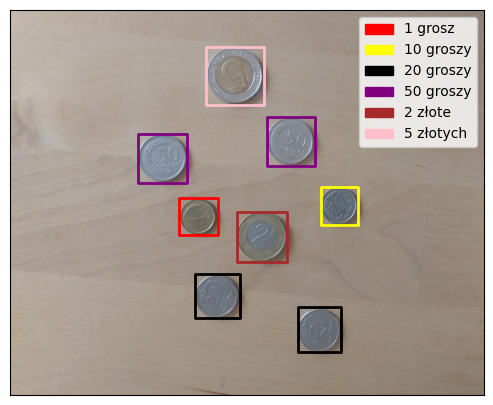

In [7]:
######################### DO NOT CHANGE THIS CELL ##########################

train_ds, val_ds = setup_data(root='./data/')

if not FINAL_EVALUATION_MODE:
    print("Number of images in training set:", len(train_ds), ", number of images in validation set:", len(val_ds))

    sample = train_ds[0]

    print("Each sample contains:", list(sample.keys()))
    print("Each image has dimensions:", list(sample["image"].shape))
    print("This sample has", sample['labels'].shape[0], "objects")
    print("Each rectangle is described as", sample['boxes'].shape[1], "values (x1, y1, x2, y2)")

    show_sample(sample) # display example image with marked objects

### Object Classes and Their Labels
Below is a table with class labels found in the dataset along with their brief description.

| Label | Description |
| --- | --- |
| 0 | 1 grosz coin |
| 1 | 2 grosze coin |
| 2 | 5 groszy coin |
| 3 | 10 groszy coin |
| 4 | 20 groszy coin |
| 5 | 50 groszy coin |
| 6 | 1 złoty coin |
| 7 | 2 złote coin |
| 8 | 5 złotych coin |


## Example Solution
Below we present a simplified solution that serves as an example demonstrating the basic functionality of the notebook. It can be used as a starting point for developing your own solution.

A simple example can be a convolutional network applied to a sliding window. This method involves extracting image fragments (in our case of typical coin sizes in the dataset) and classifying each of them with a convolutional network. This network outputs one of 10 classes: nine for different denominations, and the last class reserved for background, i.e., places where there is no coin. The classification operation is performed for each image fragment, moving by a certain step value. When the network returns the background class, we skip that fragment; otherwise, we assign the coin label to the analyzed fragment. This way, we obtain a set of rectangles containing coins.

When implementing, we need to consider an additional class representing the background (rectangle with no coin). During training, we can make random image crops. If a crop overlaps with a coin with an IoU value greater than $0.5$, we choose its denomination as the label. In case the crop does not overlap with any coin, we choose background as the label.

We will start by defining a simple model, and then in the following cells, we will implement the training function.

In [8]:
######################### DO NOT CHANGE THIS CELL ##########################

class BasicCNNClassifier(nn.Module):
    def __init__(self):
        super(BasicCNNClassifier, self).__init__()
        self.net = resnet18(weights=None, num_classes=10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Function classifying image x into one of 10 classes: 9 coins + background.

        Args:
            x (torch.Tensor): Image to classify.

        Returns:
            torch.Tensor: Model predictions.
        """
        return self.net(x)

In [9]:
######################### DO NOT CHANGE THIS CELL ##########################
# code for processing an image with multiple coins into training data for the classifier
# in 90% of cases, we randomly select an object from the image and cut out its surroundings
# in 10% of cases, we select a completely random fragment of the image

class ClassificationDataPreprocessor:
    def __init__(
            self, 
            num_of_crops_per_image: int = 4, 
            box_size: int = 64
        ):
        self.num_of_crops_per_image = num_of_crops_per_image
        self.box_size = box_size

    def get_label_of_crop(
            self, 
            crop_box: tuple, 
            boxes: torch.Tensor, 
            labels: torch.Tensor,
            iou_threshold: float = 0.5
        ) -> int:
        """
        Function returning the label for an image crop depending on whether it overlaps with a coin with IoU > 0.5.

        Args:
            crop_box (tuple): Coordinates of the top-left and bottom-right corner of the image crop (x1, y1, x2, y2).
            boxes (torch.Tensor): Tensor containing coin bounding boxes.
            labels (torch.Tensor): Tensor containing coin labels.
            iou_threshold (float): IoU threshold for matching predictions to objects.
        """
        for box, label in zip(boxes, labels):
            if box_iou(torch.tensor(crop_box).view(1, 4), box.view(1, 4)) > iou_threshold:
                return label
        return 9 # values 0-8 are coin labels, so 9 will be background

    def __call__(
            self, 
            batch: list
        ) -> dict:
        """
        Function processing images with multiple coins into training data for the classifier, containing image crops with their labels. 

        Args:
            batch (list): List of dictionaries containing images, coin bounding boxes, and their labels.

        Returns:
            dict: Dictionary containing image crops and their labels.
        """
        crops, labels = [], []

        for sample in batch:
            img = sample['image']

            for _ in range(self.num_of_crops_per_image):
                if torch.rand(1) < 0.1: # 1 in 10 times we sample background (trying to balance the dataset)
                    central_x = torch.randint(0, img.shape[2], (1,)).item()
                    central_y = torch.randint(0, img.shape[1], (1,)).item()
                else: # in the remaining 90%, we randomly select an object from the image and cut out its surroundings
                    idx_gt = torch.randint(0, sample['labels'].shape[0], (1,)).item()
                    central_x = (sample['boxes'][idx_gt, 0] + sample['boxes'][idx_gt, 2]) // 2 + torch.randint(-10, 10, (1,)).item()
                    central_y = (sample['boxes'][idx_gt, 1] + sample['boxes'][idx_gt, 3]) // 2 + torch.randint(-10, 10, (1,)).item()

                x1 = np.clip(central_x - self.box_size // 2, 0, img.shape[2] - self.box_size)
                y1 = np.clip(central_y - self.box_size // 2, 0, img.shape[1] - self.box_size)
                x2, y2 = x1 + self.box_size, y1 + self.box_size

                crop = img[:, y1:y2, x1:x2]
                label = self.get_label_of_crop((x1, y1, x2, y2), sample['boxes'], sample['labels'])

                crops.append(crop)
                labels.append(label)

        return {
            "crops": torch.stack(crops, dim=0),
            "labels": torch.tensor(labels)
        }


In [10]:
######################### DO NOT CHANGE THIS CELL ##########################
# code for validation using the sliding window method

class SlidingWindowDetector(nn.Module):
    """
    Class implementing object detection using the sliding window method. This is an example solution to the coin detection problem.

    Args:
        classifier (nn.Module): Object classifier model. For each sliding window position, 
                    the classifier returns a prediction for the given image crop.
        crop_size: Size of the sliding window
        stride: distance by which we move the window in each iteration.
    """
    def __init__(
            self, 
            classifier: nn.Module, 
            crop_size: int = 64, 
            stride: int = 32
        ):
        super(SlidingWindowDetector, self).__init__()
        self.classifier = classifier
        self.crop_size = crop_size
        self.stride = stride

    def forward(
            self, 
            image: torch.Tensor
        ) -> list:
        """
        Function predicting objects in the image using the sliding window method.

        Args:
            image: Image to process.

        Returns:
            list of found objects in the form of a tuple (x1, y1, x2, y2, label, confidence).
        """
        # move the image to the appropriate device (same as the model)
        device = next(self.parameters()).device
        image = image.to(device)

        found_objects = [] # list of objects, where each object is a tuple (x1, y1, x2, y2, label, confidence)

        # slide the window over the image
        for y in range(0, image.shape[1] - self.crop_size, self.stride):
            for x in range(0, image.shape[2] - self.crop_size, self.stride):
                crop = image[:, y:y+self.crop_size, x:x+self.crop_size]
                pred = self.classifier(crop.unsqueeze(0))[0]

                if pred.argmax() != 9: # skip background
                    label = pred.argmax().item()
                    confidence = torch.softmax(pred, dim=0)[label].item()
                    found_objects.append((x, y, x+self.crop_size, y+self.crop_size, label, confidence))

        return found_objects

In [11]:
######################### DO NOT CHANGE THIS CELL ##########################

def train_basic_detector(
        train_ds: Dataset
    ) -> SlidingWindowDetector:
    """
    Function training a coin classifier by creating image crops and classifying them. 
    When the classifier is trained, we create an object detector using the sliding window method (SlidingWindowDetector). 

    Args:
        train_ds (Dataset): Training dataset.

    Returns:
        SlidingWindowDetector: Trained object detector using the sliding window method.
    """

    # what should be the size of the sliding window? we will find the answer in the data...
    # let's calculate the average size of all objects in the training set
    total = 0
    boxes = 0

    for sample in train_ds:
        total += sum(sample["boxes"][:, 2] - sample["boxes"][:, 0]) # x2 - x1 (assuming objects are square, so we omit y)
        boxes += len(sample["boxes"])

    box_size = (total / boxes).item()

    print("Average object size in training set:", box_size) # should be about 62

    # this value is close to 64, which is a power of 2, making our network architecture easier
    box_size = 64
    preprocess = ClassificationDataPreprocessor(num_of_crops_per_image=128, box_size=box_size)

    # prepare the model, optimizer, and loss function (by using the sliding window technique, the problem of training our model has become a classification problem)
    model = BasicCNNClassifier()
    model.to(DEVICE)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # prepare dataloaders
    train_dl = torch.utils.data.DataLoader(train_ds, batch_size=2, shuffle=True, collate_fn=preprocess)

    # train the model for the selected number of epochs
    epochs = 30

    pbar = tqdm(range(epochs), desc="Training", total=epochs)
    for _ in pbar:
        epoch_losses = []

        for batch in train_dl:
            X = batch["crops"].to(DEVICE)
            y = batch["labels"].to(DEVICE)

            optimizer.zero_grad()
            output = model(X)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.detach().cpu().item())

        avg_loss = np.mean(epoch_losses)
        pbar.set_postfix({'train loss': avg_loss})

    model.eval()

    # construct an object detector using the sliding window method, which uses the trained classifier for crop prediction
    return SlidingWindowDetector(model)

In [14]:
######################### DO NOT CHANGE THIS CELL ##########################

if not FINAL_EVALUATION_MODE:
    train_ds, val_ds = setup_data(root='data/')

    # model = train_basic_detector(train_ds)
    model = BasicCNNClassifier().to(DEVICE)
    model.load_state_dict(torch.load('model.pt'))
    model = SlidingWindowDetector(model)

RuntimeError: Error(s) in loading state_dict for BasicCNNClassifier:
	Missing key(s) in state_dict: "net.conv1.weight", "net.bn1.weight", "net.bn1.bias", "net.bn1.running_mean", "net.bn1.running_var", "net.layer1.0.conv1.weight", "net.layer1.0.bn1.weight", "net.layer1.0.bn1.bias", "net.layer1.0.bn1.running_mean", "net.layer1.0.bn1.running_var", "net.layer1.0.conv2.weight", "net.layer1.0.bn2.weight", "net.layer1.0.bn2.bias", "net.layer1.0.bn2.running_mean", "net.layer1.0.bn2.running_var", "net.layer1.1.conv1.weight", "net.layer1.1.bn1.weight", "net.layer1.1.bn1.bias", "net.layer1.1.bn1.running_mean", "net.layer1.1.bn1.running_var", "net.layer1.1.conv2.weight", "net.layer1.1.bn2.weight", "net.layer1.1.bn2.bias", "net.layer1.1.bn2.running_mean", "net.layer1.1.bn2.running_var", "net.layer2.0.conv1.weight", "net.layer2.0.bn1.weight", "net.layer2.0.bn1.bias", "net.layer2.0.bn1.running_mean", "net.layer2.0.bn1.running_var", "net.layer2.0.conv2.weight", "net.layer2.0.bn2.weight", "net.layer2.0

In [ ]:
state = model.state_dict()
torch.save(state, 'model.pt')

In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################

if not FINAL_EVALUATION_MODE:
    out = predict_all_bounding_boxes(model, val_ds)

    map_val = calculate_map(out, val_ds, return_all=True)

    print(f"mAP using IoU=0.5 threshold on validation set: {map_val['map_50'].item():.2f}")
    print(f"mAP for multiple IoU values on validation set:  {map_val['map']:.2f}, this is the metric that is evaluated in the competition. Your task is to maximize it.")

    plot_detection_results_grid(out, val_ds)

    plot_confusion_matrix(out, val_ds, iou_threshold=0.5)
    plot_confusion_matrix(out, val_ds, iou_threshold=0.8)

ModuleNotFoundError: `MAP` metric requires that `pycocotools` or `faster-coco-eval` installed. Please install with `pip install pycocotools` or `pip install faster-coco-eval` or `pip install torchmetrics[detection]`.

It is worth noting the discrepancies in mAP values using the IoU=0.5 threshold and for multiple different IoU values (0.5, ..., 0.95). A similar discrepancy is visible in the confusion matrix for different IoU values. This means that the model can predict classes quite well, but has problems with precise object localization.

This is an expected result because the model uses the sliding window technique, which does not place the rectangle exactly on the coin, but only moves it by a specific value (in our case 32 pixels), which means that the positions proposed by the model are only in the vicinity of the actual coins. Additionally, the size of the returned windows is constant, which further worsens the mAP results for higher IoU thresholds.

Your task is to implement a model that improves these results.

# Your Solution
In this section, you should place your solution. Make changes only here!

In [ ]:
# here you can implement your detector, which will return a list of found objects in the format (x1, y1, x2, y2, label, confidence)

class YourDetector(nn.Module):
    def __init__(self):
        # here you can initialize your model
        super(YourDetector, self).__init__()
        pass

    def forward(
            self, 
            img: torch.Tensor
        ) -> list:
        """
        Your coin detection function for the image. 

        Args:
            img: Image to process.

        Returns:
            list of found objects in the form of a tuple (x1, y1, x2, y2, label, confidence).
        """
        # implement your detector logic here
        return []  # example model, returning an empty list

In [ ]:
# definitions of augmentations for training and validation sets. Default None means no augmentations
train_transform = None
val_transform = None

train_ds, val_ds = setup_data(train_transform, val_transform, root='data/')

# here, train your model
# ... 

your_model = YourDetector()

# Evaluation

Running the cell below will allow you to check how many points your solution would score on the validation data. Before submitting, make sure that the entire notebook runs from start to finish without errors and without user intervention after selecting the "Run All" option.

In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################

if not FINAL_EVALUATION_MODE:
    your_out = predict_all_bounding_boxes(your_model, val_ds)

    your_map_val = calculate_map(your_out, val_ds, return_all=False) # returns only averaged mAP (main evaluation criterion)

    score = (np.clip(your_map_val, 0.2, 0.85) - 0.2) / 0.65 * 100
    score = int(round(score))

    print(f"mAP on validation set: {your_map_val:.2f}")
    print(f"Estimated points for the task: {score}")

    plot_detection_results_grid(your_out, val_ds)

    plot_confusion_matrix(your_out, val_ds, iou_threshold=0.5)
    plot_confusion_matrix(your_out, val_ds, iou_threshold=0.8)

During testing, the model will be saved as `your_model.pkl` and evaluated on the test set.

In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################

if FINAL_EVALUATION_MODE:
    import cloudpickle

    # If the model has parameters, set it to evaluation mode and move to CPU
    if list(your_model.parameters()):
        your_model.eval()
        your_model.cpu()

    OUTPUT_PATH = "file_output"
    FUNCTION_FILENAME = "your_model.pkl"
    FUNCTION_OUTPUT_PATH = os.path.join(OUTPUT_PATH, FUNCTION_FILENAME)

    if not os.path.exists(OUTPUT_PATH):
        os.makedirs(OUTPUT_PATH)

    with open(FUNCTION_OUTPUT_PATH, "wb") as f:
        cloudpickle.dump(your_model, f)